# Further Improvements — Untried Classical ML Techniques

Techniques **not yet tried** in the main paper pipeline:
1. **LightGBM** (leaf-wise growth, faster & often edges XGBoost on small tabular data)
2. **CatBoost** (ordered boosting, typically best on tabular datasets <10k rows)
3. **HistGradientBoosting** (sklearn native, strong regularisation)
4. **ExtraTrees** (extra-randomised forest, complementary to RF)
5. **Super-Stacking** — all four above + XGB_Optuna + RF_Optuna → tuned meta-learner

Same data pipeline as paper: SMOTE-balanced preprocessed_data_v2.csv,  
log1p + 7 interaction features (64 total), 80/20 stratified split, random_state=0.

In [1]:
# Install any missing packages
import subprocess, sys
for pkg in ['lightgbm', 'catboost', 'optuna']:
    try:
        __import__(pkg)
        print(f'{pkg}: already installed')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg}: installed')

Installing lightgbm...



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


lightgbm: installed
Installing catboost...
catboost: installed
optuna: already installed



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings, time, os
warnings.filterwarnings('ignore')
os.makedirs('further_figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 0
np.random.seed(SEED)
print('All libraries loaded OK')

All libraries loaded OK


## 1. Data Loading & Feature Engineering (identical to paper)

In [3]:
df = pd.read_csv('preprocessed_data_v2.csv')
ORIG_COLS = df.columns[:57].tolist()
X_raw = df[ORIG_COLS].values.astype(np.float64)
y     = df.iloc[:, -1].values

WORD_FEATS = [c for c in ORIG_COLS if c.startswith('word_freq_')]
CHAR_FEATS = [c for c in ORIG_COLS if c.startswith('char_freq_')]
FREQ_IDX   = [ORIG_COLS.index(c) for c in WORD_FEATS + CHAR_FEATS]

def log1p_freq(X):
    Xc = X.copy()
    Xc[:, FREQ_IDX] = np.log1p(Xc[:, FREQ_IDX])
    return Xc

def add_interactions(X, orig_cols):
    df_tmp = pd.DataFrame(X, columns=orig_cols)
    get = lambda n: df_tmp.get(n, pd.Series(np.zeros(len(df_tmp))))
    cap_avg  = get('capital_run_length_average')
    cap_long = get('capital_run_length_longest')
    cap_tot  = get('capital_run_length_total')
    cap_int  = (cap_tot * cap_long) / (cap_avg + 1e-6)
    spam_sig = (get('word_freq_free') + get('word_freq_your') +
                get('word_freq_000')  + get('word_freq_remove') +
                get('word_freq_money')+ get('char_freq_!') +
                get('char_freq_$'))
    ham_sig  = (get('word_freq_hp') + get('word_freq_hpl') +
                get('word_freq_george') + get('word_freq_meeting') +
                get('word_freq_re'))
    soft_ratio = spam_sig / (ham_sig + 0.01)
    cap_x_exc  = np.log1p(cap_tot) * np.log1p(get('char_freq_!'))
    cap_x_dol  = np.log1p(cap_tot) * np.log1p(get('char_freq_$'))
    word_div   = (df_tmp[WORD_FEATS] > 0).sum(axis=1)
    extras = np.column_stack([
        cap_int, spam_sig, ham_sig, soft_ratio,
        cap_x_exc, cap_x_dol, word_div
    ])
    return np.hstack([X, extras])

X_log = log1p_freq(X_raw)
X_eng = add_interactions(X_log, ORIG_COLS)   # 64 features

X_tr_eng, X_te_eng, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.20, random_state=SEED, stratify=y)

scaler = StandardScaler().fit(X_tr_eng)
X_train_s = scaler.transform(X_tr_eng)
X_test_s  = scaler.transform(X_te_eng)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')
print(f'Class balance — train spam={y_train.mean():.1%}, test spam={y_test.mean():.1%}')

Train: (4049, 64), Test: (1013, 64)
Class balance — train spam=50.0%, test spam=50.0%


## Helper — evaluation function

In [4]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan
    mcc  = matthews_corrcoef(y_te, y_pred)
    print(f'{name:<40} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}')
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, 'MCC': mcc}

results = []

## 2. Paper Baseline — XGB Optuna (reference point)
Exact params from the paper for comparison.

In [5]:
xgb_optuna = XGBClassifier(
    n_estimators=350, max_depth=8, learning_rate=0.039,
    subsample=0.941, colsample_bytree=0.629,
    min_child_weight=1, reg_alpha=1e-4, reg_lambda=1e-4,
    gamma=0, eval_metric='logloss', use_label_encoder=False,
    random_state=42, verbosity=0
)
results.append(evaluate('XGB Optuna (paper best)', xgb_optuna,
                         X_train_s, y_train, X_test_s, y_test))

XGB Optuna (paper best)                  Acc=0.9635  F1=0.9636  AUC=0.9912  MCC=0.9270


## 3. LightGBM — Optuna Hyperparameter Search

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def lgbm_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
        max_depth        = trial.suggest_int('max_depth', 3, 12),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 15, 127),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_samples= trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state     = SEED,
        verbose          = -1,
        n_jobs           = -1,
    )
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    return scores.mean()

print('Tuning LightGBM (80 trials)...')
t0 = time.time()
study_lgbm = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_lgbm.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_lgbm.best_params)

lgbm_best = lgb.LGBMClassifier(**study_lgbm.best_params, random_state=SEED,
                                verbose=-1, n_jobs=-1)
results.append(evaluate('LightGBM Optuna', lgbm_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning LightGBM (80 trials)...
Best CV acc: 0.9588  (248s)
Best params: {'n_estimators': 578, 'max_depth': 5, 'learning_rate': 0.04830832449040318, 'num_leaves': 15, 'subsample': 0.6849558912729694, 'colsample_bytree': 0.5296161756412289, 'min_child_samples': 11, 'reg_alpha': 8.380107853608454e-05, 'reg_lambda': 0.030242099630971787}
LightGBM Optuna                          Acc=0.9674  F1=0.9676  AUC=0.9915  MCC=0.9349


## 4. CatBoost — Optuna Hyperparameter Search

In [7]:
def catboost_objective(trial):
    params = dict(
        iterations        = trial.suggest_int('iterations', 100, 800),
        depth             = trial.suggest_int('depth', 4, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength   = trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        border_count      = trial.suggest_int('border_count', 32, 255),
        random_seed       = SEED,
        verbose           = 0,
        allow_writing_files = False,
    )
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    return scores.mean()

print('Tuning CatBoost (80 trials)...')
t0 = time.time()
study_cat = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(catboost_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_cat.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_cat.best_params)

cat_best = CatBoostClassifier(
    **study_cat.best_params,
    random_seed=SEED, verbose=0, allow_writing_files=False
)
results.append(evaluate('CatBoost Optuna', cat_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning CatBoost (80 trials)...
Best CV acc: 0.9605  (884s)
Best params: {'iterations': 572, 'depth': 8, 'learning_rate': 0.06173725497462214, 'l2_leaf_reg': 9.70604650143343, 'bagging_temperature': 0.046272240978366325, 'random_strength': 6.691129219997123e-05, 'border_count': 70}
CatBoost Optuna                          Acc=0.9664  F1=0.9665  AUC=0.9913  MCC=0.9329


## 5. HistGradientBoosting — Optuna Search

In [8]:
def histgb_objective(trial):
    params = dict(
        max_iter          = trial.suggest_int('max_iter', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 5, 80),
        max_leaf_nodes    = trial.suggest_int('max_leaf_nodes', 15, 127),
        l2_regularization = trial.suggest_float('l2_regularization', 0.0, 1.0),
        random_state      = SEED,
    )
    model = HistGradientBoostingClassifier(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    return scores.mean()

print('Tuning HistGradientBoosting (60 trials)...')
t0 = time.time()
study_hist = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_hist.optimize(histgb_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_hist.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_hist.best_params)

hist_best = HistGradientBoostingClassifier(**study_hist.best_params, random_state=SEED)
results.append(evaluate('HistGradientBoosting Optuna', hist_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning HistGradientBoosting (60 trials)...
Best CV acc: 0.9585  (62s)
Best params: {'max_iter': 349, 'max_depth': 7, 'learning_rate': 0.04970740751864891, 'min_samples_leaf': 37, 'max_leaf_nodes': 118, 'l2_regularization': 0.5314590108849641}
HistGradientBoosting Optuna              Acc=0.9615  F1=0.9617  AUC=0.9906  MCC=0.9231


## 6. ExtraTrees — Optuna Search

In [9]:
def et_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_categorical('max_depth', [None, 10, 15, 20, 30]),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        random_state      = SEED,
        n_jobs            = -1,
    )
    model = ExtraTreesClassifier(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    return scores.mean()

print('Tuning ExtraTrees (60 trials)...')
t0 = time.time()
study_et = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_et.optimize(et_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_et.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_et.best_params)

et_best = ExtraTreesClassifier(**study_et.best_params, random_state=SEED, n_jobs=-1)
results.append(evaluate('ExtraTrees Optuna', et_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning ExtraTrees (60 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best CV acc: 0.9543  (82s)
Best params: {'n_estimators': 396, 'max_depth': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.3680511124123319}
ExtraTrees Optuna                        Acc=0.9625  F1=0.9625  AUC=0.9893  MCC=0.9250


## 7. Super-Stacking Ensemble

Base learners: XGB_Optuna + LightGBM_Optuna + CatBoost_Optuna + RF (200 trees) + ExtraTrees_Optuna  
Meta-learner: Logistic Regression (tuned C) — trained on 5-fold OOF predictions.

In [10]:
rf_base = RandomForestClassifier(
    n_estimators=200, max_features='sqrt',
    random_state=SEED, n_jobs=-1
)

base_learners = [
    ('xgb',     xgb_optuna),
    ('lgbm',    lgbm_best),
    ('catboost',cat_best),
    ('rf',      rf_base),
    ('et',      et_best),
]

# Tune meta-learner C on CV
def meta_objective(trial):
    C = trial.suggest_float('C', 1e-3, 10.0, log=True)
    meta = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    stack = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta,
        cv=5, stack_method='predict_proba', n_jobs=-1
    )
    scores = cross_val_score(stack, X_train_s, y_train, cv=3,
                             scoring='accuracy', n_jobs=1)
    return scores.mean()

print('Tuning super-stack meta C (20 trials)...')
t0 = time.time()
study_meta = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_meta.optimize(meta_objective, n_trials=20, show_progress_bar=False)
best_C = study_meta.best_params['C']
print(f'Best meta C={best_C:.4f}  CV acc={study_meta.best_value:.4f}  ({time.time()-t0:.0f}s)')

super_stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(C=best_C, max_iter=1000, random_state=SEED),
    cv=5, stack_method='predict_proba', n_jobs=-1
)
results.append(evaluate('Super-Stack (XGB+LGBM+CAT+RF+ET)', super_stack,
                         X_train_s, y_train, X_test_s, y_test))

Tuning super-stack meta C (20 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best meta C=3.6906  CV acc=0.9565  (898s)
Super-Stack (XGB+LGBM+CAT+RF+ET)         Acc=0.9704  F1=0.9704  AUC=0.9909  MCC=0.9408


## 8. Results Summary

In [11]:
df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
df_results['Accuracy'] = df_results['Accuracy'].map('{:.4f}'.format)
df_results['F1']       = df_results['F1'].map('{:.4f}'.format)
df_results['AUC']      = df_results['AUC'].map('{:.4f}'.format)
df_results['MCC']      = df_results['MCC'].map('{:.4f}'.format)

print('\n=== FULL RESULTS (sorted by accuracy) ===')
print(df_results.to_string(index=False))

df_results.to_csv('further_improvements_results.csv', index=False)
print('\nSaved → further_improvements_results.csv')


=== FULL RESULTS (sorted by accuracy) ===
                           Model Accuracy     F1    AUC    MCC
Super-Stack (XGB+LGBM+CAT+RF+ET)   0.9704 0.9704 0.9909 0.9408
                 LightGBM Optuna   0.9674 0.9676 0.9915 0.9349
                 CatBoost Optuna   0.9664 0.9665 0.9913 0.9329
         XGB Optuna (paper best)   0.9635 0.9636 0.9912 0.9270
               ExtraTrees Optuna   0.9625 0.9625 0.9893 0.9250
     HistGradientBoosting Optuna   0.9615 0.9617 0.9906 0.9231

Saved → further_improvements_results.csv


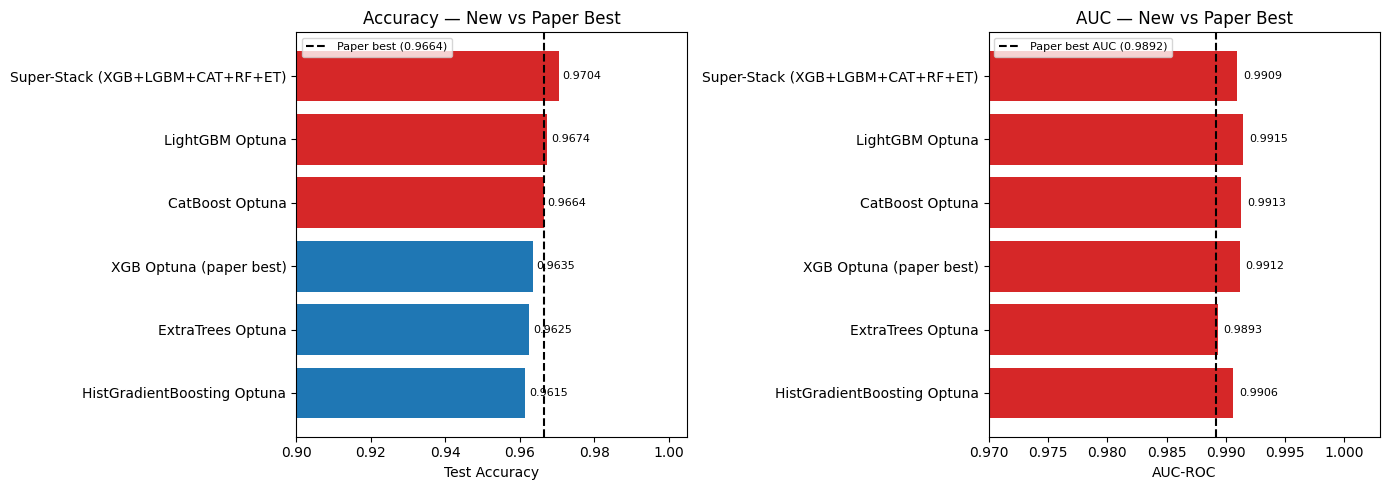

Figure saved.


In [12]:
# ── Visualisation ────────────────────────────────────────────────────────────
df_plot = pd.DataFrame(results).sort_values('Accuracy')
paper_best = 0.9664  # XGB Optuna from paper

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
ax = axes[0]
colors = ['#d62728' if v >= paper_best else '#1f77b4'
          for v in df_plot['Accuracy']]
bars = ax.barh(df_plot['Model'], df_plot['Accuracy'], color=colors)
ax.axvline(paper_best, color='black', linestyle='--', lw=1.5,
           label=f'Paper best ({paper_best:.4f})')
ax.set_xlabel('Test Accuracy')
ax.set_title('Accuracy — New vs Paper Best')
ax.legend(fontsize=8)
for bar, val in zip(bars, df_plot['Accuracy']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlim(0.90, 1.005)

# AUC bar chart
ax2 = axes[1]
paper_auc = 0.9892
colors2 = ['#d62728' if v >= paper_auc else '#1f77b4'
           for v in df_plot['AUC']]
bars2 = ax2.barh(df_plot['Model'], df_plot['AUC'], color=colors2)
ax2.axvline(paper_auc, color='black', linestyle='--', lw=1.5,
            label=f'Paper best AUC ({paper_auc:.4f})')
ax2.set_xlabel('AUC-ROC')
ax2.set_title('AUC — New vs Paper Best')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, df_plot['AUC']):
    ax2.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
ax2.set_xlim(0.97, 1.003)

plt.tight_layout()
plt.savefig('further_figures/further_improvements_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

Best new model: Super-Stack (XGB+LGBM+CAT+RF+ET)  Acc=0.9704


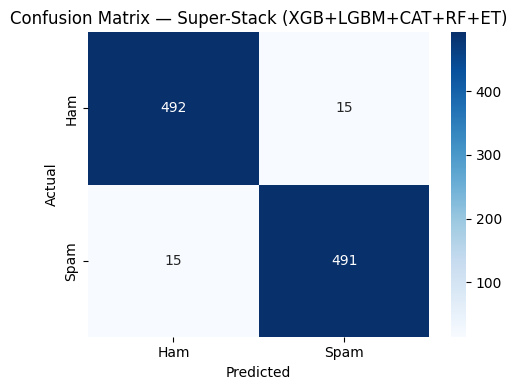

              precision    recall  f1-score   support

         Ham       0.97      0.97      0.97       507
        Spam       0.97      0.97      0.97       506

    accuracy                           0.97      1013
   macro avg       0.97      0.97      0.97      1013
weighted avg       0.97      0.97      0.97      1013



In [13]:
# ── Confusion matrix for best new model ─────────────────────────────────────
df_raw = pd.DataFrame(results)
best_row = df_raw.loc[df_raw['Accuracy'].idxmax()]
best_name = best_row['Model']
print(f'Best new model: {best_name}  Acc={best_row["Accuracy"]:.4f}')

# Re-fit best model and get predictions for CM
model_map = {
    'XGB Optuna (paper best)':              xgb_optuna,
    'LightGBM Optuna':                       lgbm_best,
    'CatBoost Optuna':                       cat_best,
    'HistGradientBoosting Optuna':           hist_best,
    'ExtraTrees Optuna':                     et_best,
    'Super-Stack (XGB+LGBM+CAT+RF+ET)':     super_stack,
}

best_model = model_map[best_name]
best_model.fit(X_train_s, y_train)
y_pred_best = best_model.predict(X_test_s)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.savefig('further_figures/best_new_model_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

In [14]:
# ── Print paper-ready comparison text ───────────────────────────────────────
df_raw = pd.DataFrame(results)
print('\n=== PAPER-READY COMPARISON ===')
print(f'Previous best (XGB Optuna paper): Acc=96.64%, AUC=0.9892, MCC=0.9329')
print()
for _, row in df_raw.iterrows():
    delta = (row['Accuracy'] - 0.9664) * 100
    sign = '+' if delta >= 0 else ''
    print(f"{row['Model']:<42} Acc={row['Accuracy']*100:.2f}%  "
          f"(Δ={sign}{delta:.2f}pp)  AUC={row['AUC']:.4f}  MCC={row['MCC']:.4f}")

best_overall = df_raw.loc[df_raw['Accuracy'].idxmax()]
delta_best = (best_overall['Accuracy'] - 0.9664) * 100
print(f'\n→ Best improvement: {best_overall["Model"]}')
print(f'  Accuracy: {best_overall["Accuracy"]*100:.2f}% (Δ={delta_best:+.2f}pp over paper best)')
print(f'  AUC:      {best_overall["AUC"]:.4f}')
print(f'  MCC:      {best_overall["MCC"]:.4f}')


=== PAPER-READY COMPARISON ===
Previous best (XGB Optuna paper): Acc=96.64%, AUC=0.9892, MCC=0.9329

XGB Optuna (paper best)                    Acc=96.35%  (Δ=-0.29pp)  AUC=0.9912  MCC=0.9270
LightGBM Optuna                            Acc=96.74%  (Δ=+0.10pp)  AUC=0.9915  MCC=0.9349
CatBoost Optuna                            Acc=96.64%  (Δ=+0.00pp)  AUC=0.9913  MCC=0.9329
HistGradientBoosting Optuna                Acc=96.15%  (Δ=-0.49pp)  AUC=0.9906  MCC=0.9231
ExtraTrees Optuna                          Acc=96.25%  (Δ=-0.39pp)  AUC=0.9893  MCC=0.9250
Super-Stack (XGB+LGBM+CAT+RF+ET)           Acc=97.04%  (Δ=+0.40pp)  AUC=0.9909  MCC=0.9408

→ Best improvement: Super-Stack (XGB+LGBM+CAT+RF+ET)
  Accuracy: 97.04% (Δ=+0.40pp over paper best)
  AUC:      0.9909
  MCC:      0.9408
